In [1]:
import json
import matplotlib.pyplot as plt

#### Func

In [2]:
def make(name: str):
    with open(f'{name}.json', 'r') as file:
        db = json.load(file)

    anios_min = min(min(años.keys()) for años in db.values())
    anios_max = max(max(años.keys()) for años in db.values())
    
    fig, ax = plt.subplots(figsize=(16, 16))
    
    for nombre, anios_nombre in db.items():
        anios_ordenados = sorted(anios_nombre.keys(), key=int)
        
        segmentos_x = []
        segmentos_y = []
        puntos_x = []
        puntos_y = []
        tamaños_puntos = []
        
        for i in range(len(anios_ordenados)):
            año = anios_ordenados[i]
            tamaño_punto = anios_nombre[año] * 10
            
            if i > 0 and int(anios_ordenados[i]) == int(anios_ordenados[i - 1]) + 1:
                segmentos_x.append(int(anios_ordenados[i - 1]))
                segmentos_y.append(nombre)
                segmentos_x.append(int(anios_ordenados[i]))
                segmentos_y.append(nombre)
            else:
                puntos_x.append(int(anios_ordenados[i]))
                puntos_y.append(nombre)
                tamaños_puntos.append(tamaño_punto)
    
        if segmentos_x:
            ax.plot(segmentos_x, segmentos_y, marker='o', linestyle='-', color='b')
        
        if puntos_x:
            ax.scatter(puntos_x, puntos_y, s=tamaños_puntos, alpha=0.6)
    
    años_range = list(range(int(anios_min), int(anios_max) + 1))
    ax.set_xticks(años_range)
    ax.set_xticklabels(años_range, rotation=90)
    
    ax.set_xlim(int(anios_min), int(anios_max))
    ax.set_xlabel('Collection Year')
    ax.set_ylabel('SISTR1 Serovar')
    ax.set_title(f'SISTR1 Serovar {name} Time Ranges')
    ax.grid(True)
    
    plt.tight_layout()
    plt.savefig(f'timeline_{name}.png', format='png')
    plt.show()

### HC20

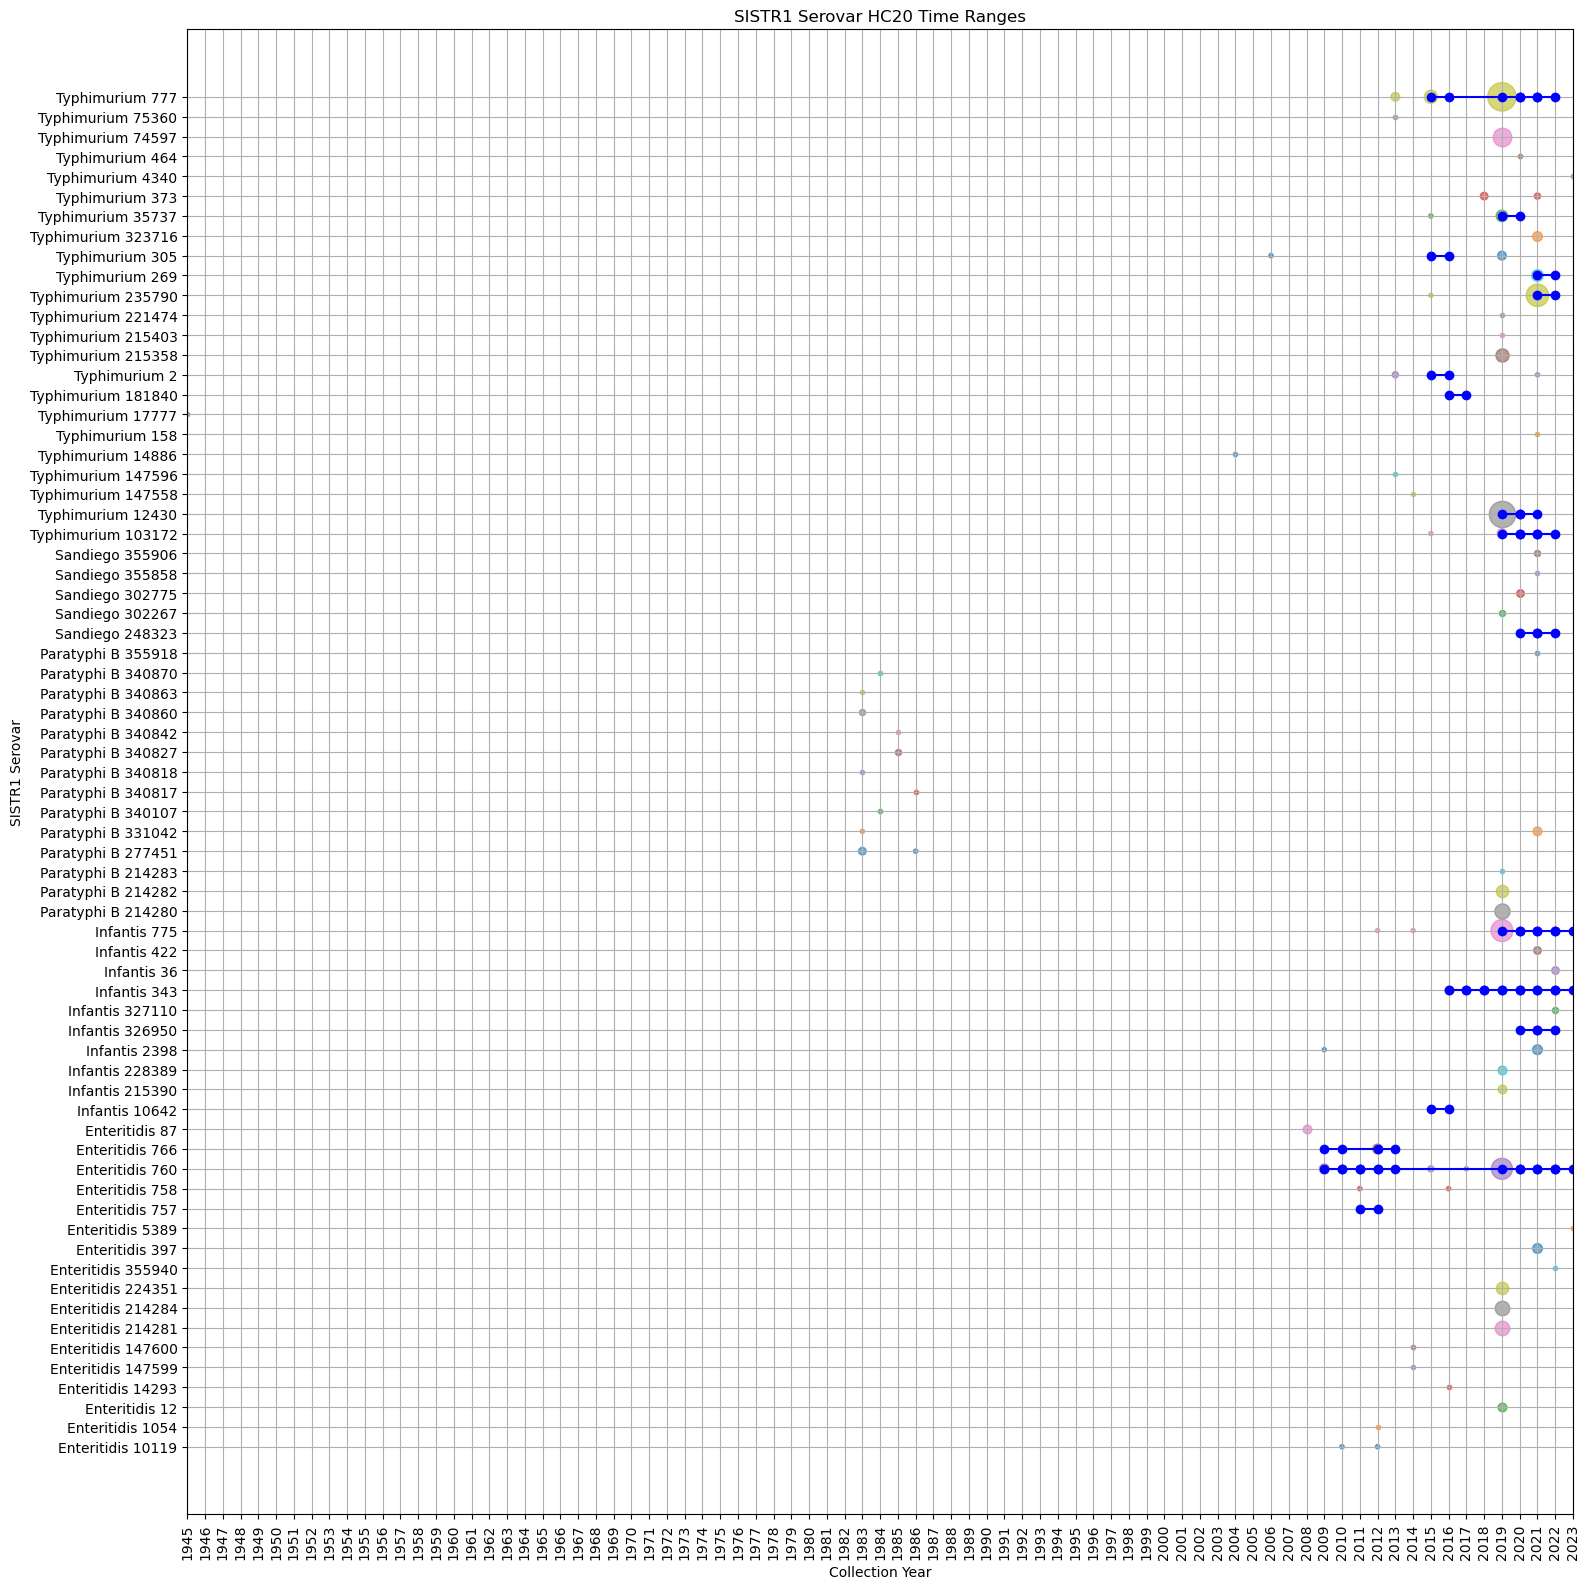

In [3]:
make('HC20')

### HC50

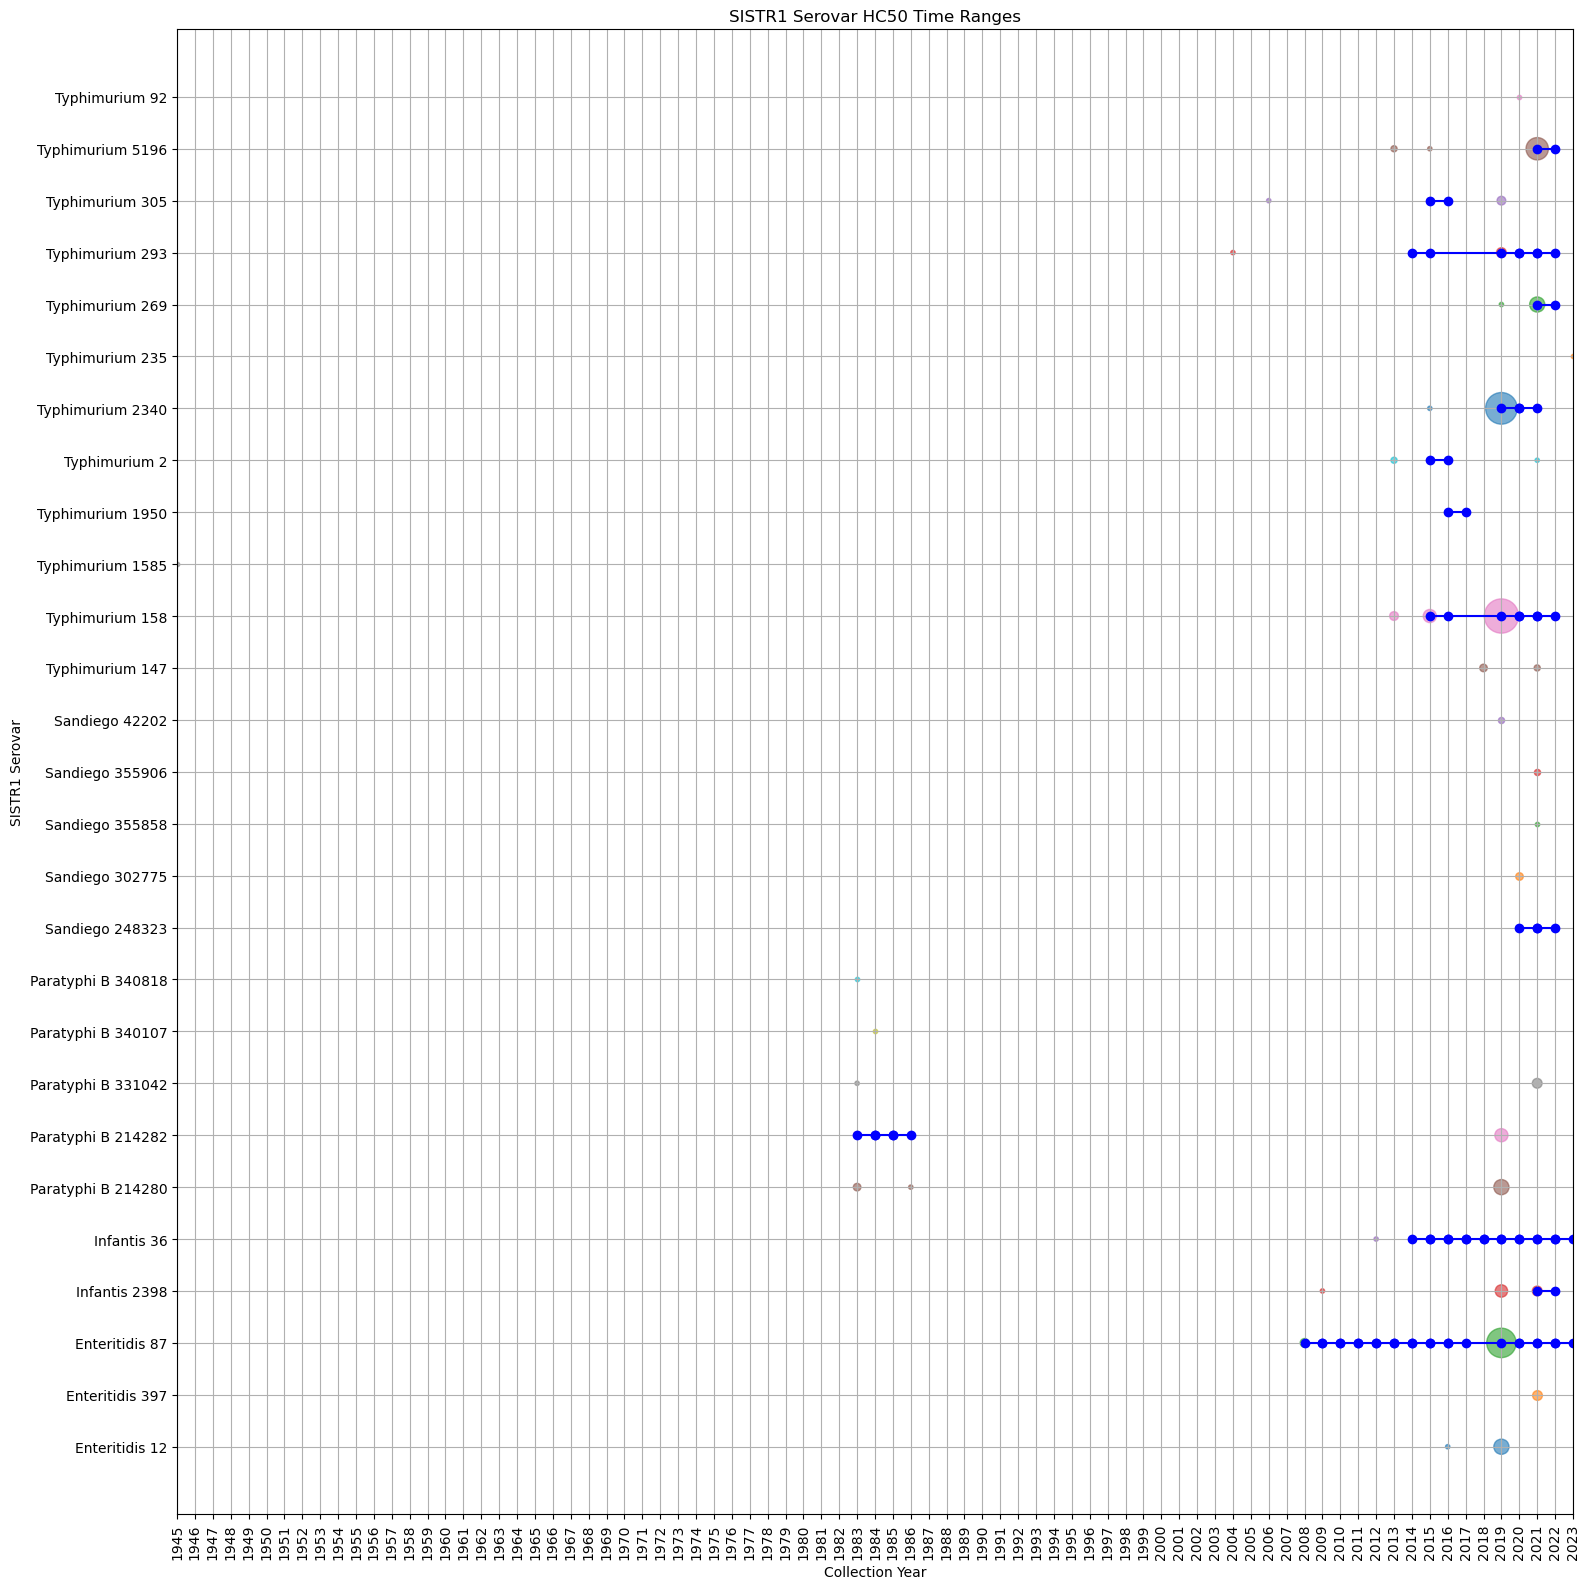

In [4]:
make('HC50')